# Práctica 1: Obteniendo el potencial y el campo eléctrico a partir de una distribución de carga

Por la 1ª ley de Maxwell, se tiene que una distribución de carga $\rho$ genera un potencial eléctrico $\phi$

$$\nabla^2 \phi(\textbf{r})=-\frac{\rho(\textbf{r})}{\epsilon_0},$$

que, en coordenadas cartesianas en dos dimensiones, toma la forma

$$\left(\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2}\right) \phi(x,y)=-\frac{\rho(x,y)}{\epsilon_0}.$$

Veremos cómo resolver esta ecuación en derivadas parciales (EDP) en el Tema 8. Sin embargo, puede obtenerse la solución de la ecuación a partir de la función de Green asociada, es decir, resolviendo la siguiente integral extendida a todo el espacio

$$\phi(\textbf{r})=\frac{1}{4 \pi \epsilon_0}\int\int \frac{\rho(\textbf{r'})}{|\textbf{r}-\textbf{r'}|}d^2\textbf{r'}.$$

1. **[2 pts]** Dada la siguiente distribución de carga bidimensional en polares,

    $$\rho(r,\varphi)=
  \left\{ 
    \begin{array}{cc}
      \rho_0e^{-\frac{1}{1-r^3}}\sin(8\varphi) &\hspace{5mm} 0\leq r <1 , \hspace{5mm} 0\leq \varphi \leq2\pi \\
      0 & \hspace{5mm} \text{en otro caso}
    \end{array} \right.
    \,,$$

    con $\rho_0=100 \, \text{C}\,\text{m}^{-3}$, representarla para $-1\leq x\leq 1$, $-1\leq y\leq 1$ (coordenadas cartesianas) en un grid $1000\times 1000$. 
    
    $\textbf{Ayuda:}$ 
    - Para ello, podría ser de ayuda utilizar el comando $\textbf{vectorize}$.
    - Para calcular de forma correcta $\arctan(y/x)$, se recomienda el uso de la función $\textbf{arctan2(y,x)}$ de $\textbf{numpy}$.
    - Se recomienda utilizar el patrón de color $\textbf{seismic}$ de $\textbf{imshow}$.

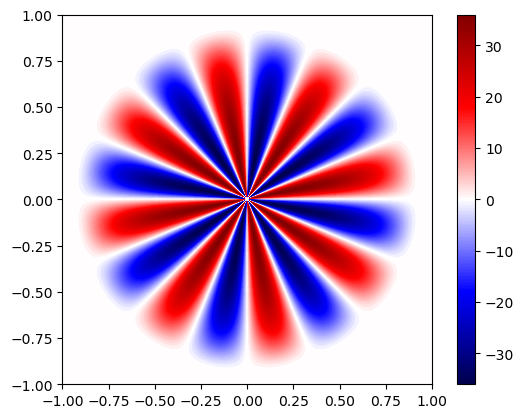

In [9]:
import numpy as np
import matplotlib.pyplot as plt

p0 = 100

t = np.linspace(-1,1,1000)

X, Y = np.meshgrid(t, t)

def p(r, theta):
    if r > 1:
        return 0
    return p0*np.exp(-1/(1-r**3))*np.sin(8*theta)

p = np.vectorize(p)
R = np.sqrt(X**2+Y**2)
THETA = np.arctan2(Y, X)

Z = p(R, THETA)

plt.imshow(Z, extent=[-1,1,-1,1], origin="lower", cmap="seismic")
plt.colorbar()
plt.show()

2. **[3,5 pts]** Definir una función que proporcione el potencial eléctrico $\phi$ generado por la distribución de carga del apartado anterior (recuerda que $\epsilon_0=8.85\times 10^{-12}\,\text{C}^2\,\text{N}^{-1}\,\text{m}^{-2}$). Justificar el método de integración utilizado.

    $\textbf{Ayuda:}$ 
    - Integrar la distribución de carga en el dominio donde es distinta de $0$, no en todo el espacio.
    - Si se calcula la integral en polares, prestar atención al elemento diferencial de superficie.

In [7]:
import numpy as np

a = 0
b = 1

N = 200
w = np.ones(N)
w[0] = w[-1] = 1/2
x = np.linspace(a,b,N)
h = x[1]-x[0]

f = lambda x: x**2

I = h*np.sum(w*f(x))

Debemos ahora calcular la integral de $\rho$ en todo el espacio donde haya densidad de carga. Esto es, en polares, en el rectángulo $r\in(0,1); \theta\in(0,2\pi)$. La integral es como sigue:

$$\phi(r,\theta) = \frac{1}{4\pi\varepsilon_0}\int_0^{2\pi}\int_0^1 \frac{\rho(r',\theta')}{|r'(\cos(\theta'), \sin(\theta'))-r(\cos(\theta), \sin(\theta))|}r'dr'd\theta'$$

In [45]:
# import numpy as np

# k = 1/(4*np.pi*8.85*10**(-12))

# N = 100

# r_p = np.linspace(0,0.99,N)
# h_r = r_p[1]-r_p[0]
# theta_p = np.linspace(0,2*np.pi,N)
# h_theta = theta_p[1]-theta_p[0]

# w = np.ones(N)
# w[0] = w[-1] = 1/2

# def V(r, theta):
#     f = lambda r_p, theta_p: p(r_p, theta_p) / np.sqrt(r**2+r_p**2-2*r*r_p*(np.cos(theta)*np.cos(theta_p)+np.sin(theta)*np.sin(theta_p)))
#     I = 0
#     for i in range(len(r_p)):
#         for j in range(len(theta_p)):
#             I += w[i]*w[j]*f(r_p[i], theta_p[j])
#     return I*h_r*h_theta*k

import numpy as np
from gaussxw import gaussxw

N = 100

x, w = gaussxw(N)

a=0
b = 1
r_p = 1/2*((b-a)*x+(b+a))
w_p = 1/2*(b-a)*w

a=0
b = 2*np.pi
theta_p = 1/2*((b-a)*x+(b+a))
w_theta = 1/2*(b-a)*w

def V(r, theta):
    f = lambda r_p, theta_p: p(r_p, theta_p) / np.sqrt(r**2+r_p**2-2*r*r_p*(np.cos(theta)*np.cos(theta_p)+np.sin(theta)*np.sin(theta_p)))
    I = 0
    for i in range(len(r_p)):
        for j in range(len(theta_p)):
            I += w[i]*w[j]*f(r_p[i], theta_p[j])
    return I*k

3. **[1 pt]** Representar el potencial eléctrico para $-2\leq x\leq 2$, $-2\leq y\leq 2$ en un grid $200\times 200$ (se recomienda utilizar $v_{max}=10^{11}\,$V y $v_{min}=-10^{11}\,$V en $\textbf{imshow}$).

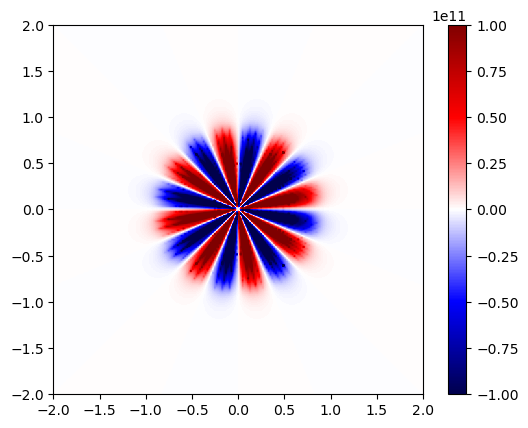

In [60]:
t = np.linspace(-2,2,200)

X, Y = np.meshgrid(t, t)

R = np.sqrt(X**2+Y**2)
THETA = np.arctan2(Y, X)

Z = V(R, THETA)

plt.imshow(Z, origin="lower", extent=[-2,2,-2,2], cmap="seismic", vmin=-10**11, vmax=10**11)
plt.colorbar()
plt.show()

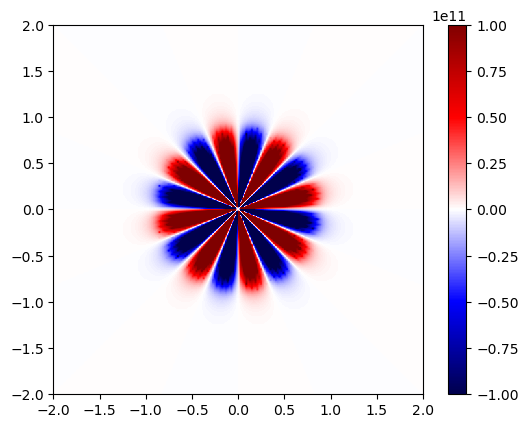

In [33]:
t = np.linspace(-2,2,200)

X, Y = np.meshgrid(t, t)

R = np.sqrt(X**2+Y**2)
THETA = np.arctan2(Y, X)

Z = V(R, THETA)

plt.imshow(Z, origin="lower", extent=[-2,2,-2,2], cmap="seismic", vmin=-10**11, vmax=10**11)
plt.colorbar()
plt.show()

4. **[2,5 pts]** A partir del potencial eléctrico, puede calcularse el campo eléctrico, en un régimen electrostático, de la siguiente forma

    $$\textbf{E}=- \boldsymbol{\nabla} \phi,$$

    que en coordenadas cartesianas bidimensionales, toma la forma
    
    $$E_x=-\frac{\partial \phi}{\partial x} \hspace{3mm},\hspace{3mm}E_y=-\frac{\partial \phi}{\partial y}.$$
    
    Calcular el campo eléctrico en $-2\leq x\leq 2$, $-2\leq y\leq 2$ a partir de la función definida en el apartado 2 (es decir, el potencial eléctrico $\phi$) en un grid $60\times 60$.

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Hacemos derivada adelant. / ret. en los extremos y en el resto de puntos hacemos der. cent

# Código para gradiente de un campo escalar. En los extremos hacemos derivadas adelantadas y retrasadas,
# y en el resto las hacemos centradas
        
# Cuando tenemos V con puntos
def der_x(V):
    der_x = np.empty_like(V)

    der_x[:,0] = V[:,1]-V[:,0]
    der_x[:,-1] = V[:,-1]-V[:,-2]
    for i in range(1,len(V)-1):
        der_x[:,i] = (V[:,i+1]-V[:,i-1])/2
    return der_x

def grad_pts(V): # Funciona exactamente igual que numpy.gradient
    gradx = der_x(V)
    grady = der_x(V.T).T
    
    return (gradx, grady)

In [62]:
t = np.linspace(-2,2,60)

X, Y = np.meshgrid(t, t)

R = np.sqrt(X**2+Y**2)
THETA = np.arctan2(Y, X)

Z = -1*V(R, THETA)

gradx, grady = grad_pts(Z)

5. **[1 pt]** Representar el campo eléctrico calculado en el apartado anterior mediante el comando $\textbf{quiver}$ del paquete $\textbf{matplotlib.pyplot}$ (una vez calculados $E_x$ y $E_y$, basta hacer uso de $\textbf{quiver}(E_x,E_y)$).

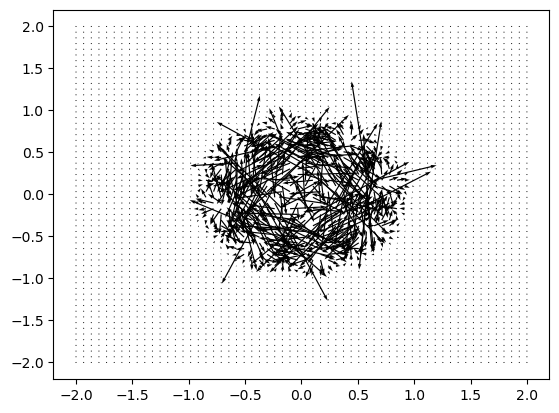

In [63]:
plt.quiver(X, Y,gradx, grady)
plt.show()

6. **[Extra: 1 pt]** Si has llegado al resultado correcto, observarás que el campo tiene una simetría parecida a la distribución de carga, pero en algunos puntos el módulo del campo eléctrico es muy elevado. Ello ocurre cuando se calcula $\phi$ en un punto muy cercano a uno de los puntos donde se evalúa el integrando, de forma que éste se vuelve muy grande y puede haber errores numéricos. Vuelve a representar $E_x$ y $E_y$, pero esta vez cuando $|E_{x,y}|>C$ (por ejemplo, $C=10^{11}\, \text{N}\,\text{C}^{-1}$), sustituye $|E_{x,y}|=C$, y obtendrás el mismo resultado que en el apartado anterior, pero evitando los errores numéricos.

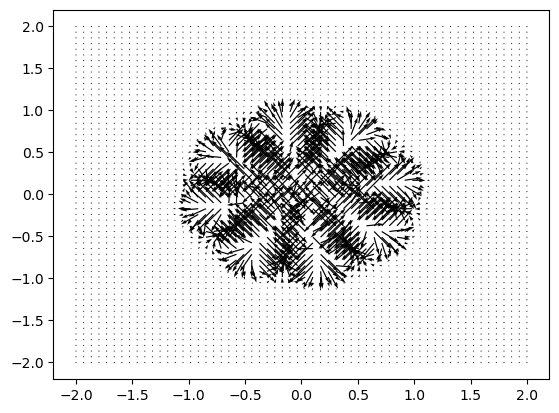

In [67]:
E = np.sqrt(gradx**2+grady**2)

C=0.07*10**11

gradx[gradx>C] = C
gradx[gradx<-C]=-C

grady[grady>C] = C
grady[grady<-C]=-C

plt.quiver(X, Y,gradx, grady)
plt.show()